# Tips Dataset — Exploratory Data Analysis

## Objective
Perform complete EDA on the Tips dataset to identify key factors 
that influence tip amount.

## Dataset
- Source: Seaborn built-in Tips dataset
- Rows: 244 restaurant bills
- Target: tip (continuous — regression problem)

## Step 1 — Load Data
Loading the dataset and performing initial exploration to understand 
structure, shape, and basic statistics.

In [1]:
import seaborn as sns
df=sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [3]:
df.shape

(244, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Step 2 — Handling Missing Values
Checking for missing values in all columns.
Tips dataset is clean — no missing values found.

In [6]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Step 3 — Data Types & Feature Selection
Checking data types — all correct, no fixes needed.
sex, smoker, day, time are category dtype (Seaborn default).

In [7]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

## Step 4 — Removing Duplicates
Checking and removing duplicate rows to avoid model bias.

In [8]:
df.duplicated().sum()

1

In [9]:
df=df.drop_duplicates()

## Step 5 — Outlier Detection & Removal
Checking continuous numeric columns using IQR method.
- total_bill: checked for outliers
- size: checked for outliers

In [10]:
nums_cols=df.select_dtypes(include='number').columns.tolist()
outlier_cols=[col for col in nums_cols if df[col].nunique() >10]
print(outlier_cols)

['total_bill', 'tip']


In [11]:
for cols in outlier_cols:
    q1=df[cols].quantile(0.25)
    q3=df[cols].quantile(0.75)
    IQR=q3 -q1
    lower=q1 -IQR *1.5
    upper=q3 +IQR *1.5
    df = df[(df[cols] >= lower) & (df[cols] <= upper)]


In [12]:
df.shape

(227, 7)

In [13]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Step 6 — Encoding Categorical Variables
Encoding reference:
- sex: Male=1, Female=0 (binary → map)
- smoker: Yes=1, No=0 (binary → map)
- time: Dinner=1, Lunch=0 (binary → map)
- day: nominal 4 categories → one-hot encoding (Thur dropped as reference)

In [14]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns


In [15]:
for col in cat_cols:
    n = df[col].nunique()
    if n == 2:
        print(f"{col} → binary → use map")
    elif n <= 5:
        print(f"{col} → check if ordinal or nominal")
    else:
        print(f"{col} → nominal → use one-hot")

sex → binary → use map
smoker → binary → use map
day → check if ordinal or nominal
time → binary → use map


In [16]:
df["day"].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [17]:
df["sex"]=df["sex"].map({"Male":1,"Female":0})
df["smoker"]=df["smoker"].map({"Yes":1,"No":0})
df["time"]=df["time"].map({"Lunch":1,"Dinner":0})

In [18]:
import pandas as pd
df=pd.get_dummies(df,columns=["day"],drop_first=True,dtype=int)

In [19]:
df.head()

,total_bill,tip,sex,smoker,time,size,day_Fri,day_Sat,day_Sun
0,16.99,1.01,0,0,0,2,0,0,1
1,10.34,1.66,1,0,0,3,0,0,1
2,21.01,3.50,1,0,0,3,0,0,1
3,23.68,3.31,1,0,0,2,0,0,1
4,24.59,3.61,0,0,0,4,0,0,1


## Step 7 — Train Test Split & Feature Scaling
Split data before scaling to prevent data leakage.
StandardScaler applied on train only — fit_transform on train, transform on test.
- Test size: 20%, Random state: 42

In [20]:
from sklearn.model_selection import train_test_split 
X=df.drop(columns=["tip"])
y=df["tip"]

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
nums_cols=X_train.select_dtypes(include="number").columns

sc=StandardScaler()
X_train[nums_cols]=sc.fit_transform(X_train[nums_cols])
X_test[nums_cols]=sc.transform(X_test[nums_cols])

In [23]:
X_train.head()

,total_bill,sex,smoker,time,size,day_Fri,day_Sat,day_Sun
63,-0.023557,1,1,0,1.757964,-0.300602,1.304413,-0.677995
173,1.795744,1,1,0,-0.573109,-0.300602,-0.766629,1.474937
71,-0.187240,0,0,0,0.592427,-0.300602,1.304413,-0.677995
195,-1.463167,1,0,1,-0.573109,-0.300602,-0.766629,-0.677995
232,-0.919791,1,0,0,-0.573109,-0.300602,1.304413,-0.677995


## Step 8 — Visualizations

### 8.1 Correlation Heatmap
Identifying features with strongest relationship with tip target.

### 8.2 Feature Distributions
Understanding shape and spread of important features.

### 8.3 Feature vs Target
How each feature impacts tip amount.

In [24]:
corr_df = X_train.copy()
corr_df['tip'] = y_train.values

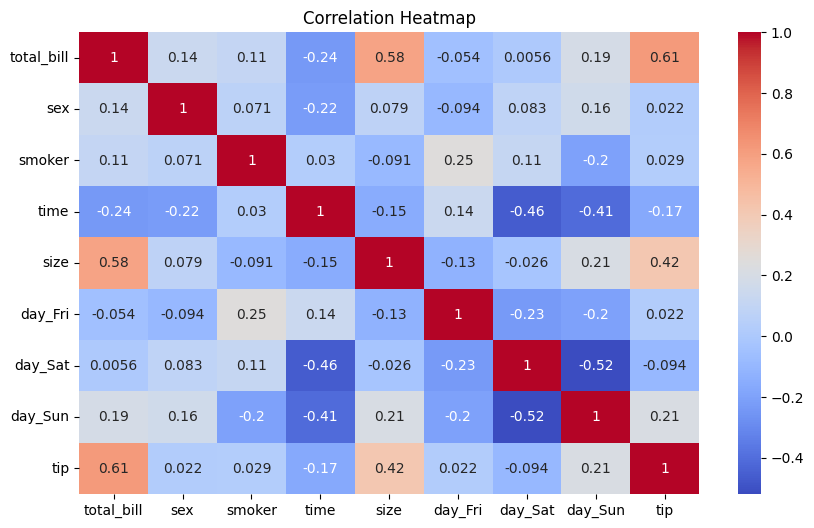

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(corr_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
corr_with_target=df.corr()["tip"].abs().sort_values(ascending=False)
important_features = corr_with_target[corr_with_target > 0.2].index.tolist()
important_features.remove("tip")
print(important_features)

['total_bill', 'size', 'day_Sun']


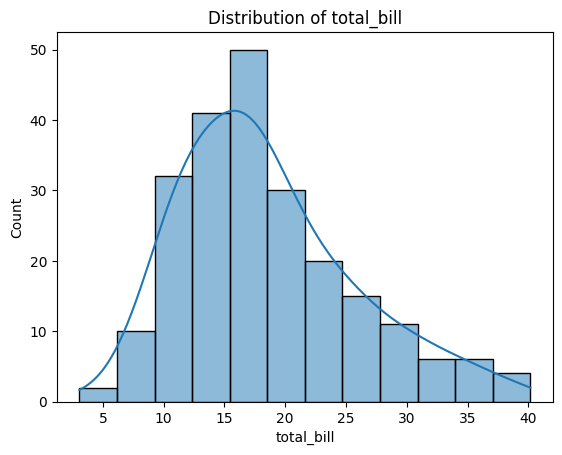

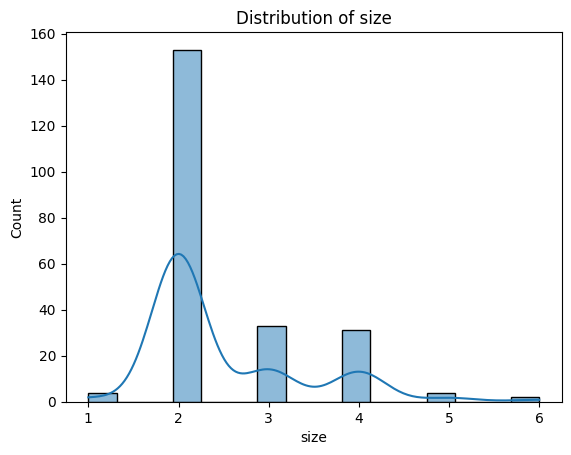

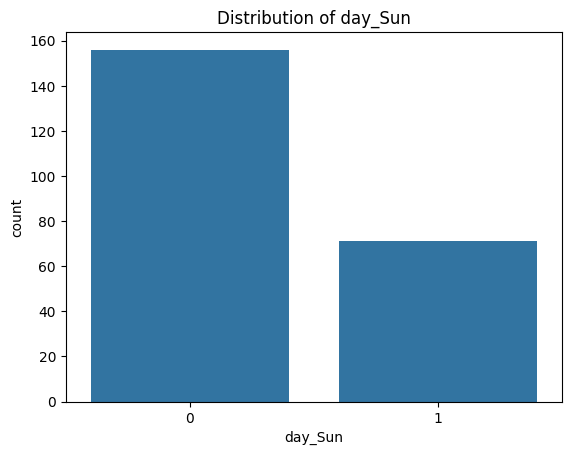

In [27]:
for col in important_features:
    if df[col].nunique() > 2:
        sns.histplot(df[col], kde=True)
    else:
        sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

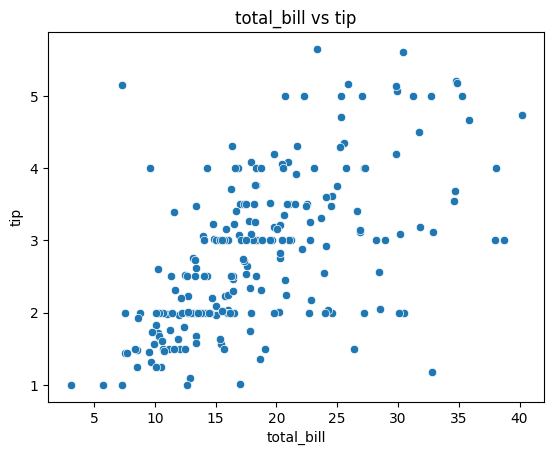

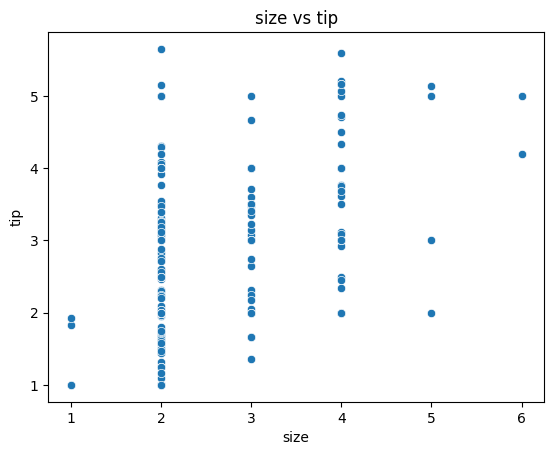

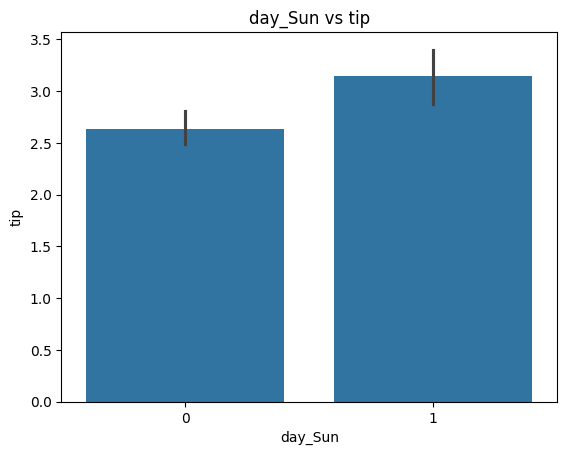

In [28]:
# Continuous vs target
for col in ['total_bill', 'size']:
    sns.scatterplot(x=df[col], y=df['tip'])
    plt.title(f"{col} vs tip")
    plt.show()

# Binary vs target
sns.barplot(x=df['day_Sun'], y=df['tip'])
plt.title("day_Sun vs tip")
plt.show()

    ## Key Findings & Observations

1. **total_bill** — strongest predictor (correlation 0.61). 
   Higher bill = higher tip. Strong positive linear relationship.

2. **size** — second strongest (correlation 0.42). 
   Larger party size tends to tip more but with high variance.

3. **day_Sun** — weak predictor (correlation 0.21). 
   Sunday visitors tip slightly more (~3.1 vs ~2.7 average).

## Conclusion
total_bill and size are the top 2 features for predicting tip amount.
Linear Regression should perform well given the linear relationship 
between total_bill and tip.